# Benchmark CPU vs GPU sur Opérations Vectorielles
## Comparaison des performances entre calcul séquentiel, calcul vectorisé CPU et calcul GPU (CuPy)

**Auteur :** NOHAILA ICHOU

**Objectif :** Comparer les performances de trois approches de calcul (boucle Python pure, NumPy vectorisé, GPU via CuPy) sur des opérations vectorielles élémentaires, et mesurer l'accélération obtenue selon la taille des données.

---

### Plan du notebook
1. Introduction théorique
2. Installation & imports
3. Génération des données de test
4. Implémentation CPU (boucle Python pure)
5. Implémentation CPU vectorisée (NumPy)
6. Implémentation GPU (CuPy avec repli NumPy)
7. Benchmark comparatif multi-tailles
8. Visualisation des résultats
9. Analyse des résultats
10. Conclusion

---
## 1. Introduction Théorique

### Opérations vectorielles
Une opération vectorielle applique la même instruction à tous les éléments d'un vecteur, par exemple l'addition terme à terme de deux vecteurs $\vec{a}$ et $\vec{b}$ :

$$c_i = a_i + b_i, \quad \forall i \in [0, n[$$

### Pourquoi paralléliser ?
Chaque élément $c_i$ est **indépendant** des autres : ce type de calcul est dit *embarrassingly parallel*. C'est le cas idéal pour :
- Le **SIMD** (Single Instruction Multiple Data) des CPU modernes, exploité par NumPy.
- Le **GPU**, qui possède des milliers de cœurs capables de traiter simultanément des milliers d'éléments.

### Ce que l'on compare
| Approche | Principe |
|----------|----------|
| Boucle Python pure | Un `for` classique, élément par élément |
| NumPy vectorisé | Instructions SIMD sur CPU, code C compilé |
| GPU (CuPy) | Exécution massivement parallèle sur cœurs CUDA |

On s'attend à ce que le gain du GPU ne devienne significatif que pour de **grands volumes de données**, car le transfert mémoire CPU → GPU a un coût fixe non négligeable.

---
## 2. 📦 Installation & Imports

In [2]:
# Installation des dépendances (CuPy nécessite un GPU + CUDA, sinon repli automatique sur NumPy)
import sys
%pip install numpy matplotlib pandas -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# Vérification de la disponibilité du GPU via CuPy
try:
    import cupy as cp
    GPU_AVAILABLE = cp.cuda.is_available()
except Exception:
    GPU_AVAILABLE = False

print("="*55)
print(" ENVIRONNEMENT DE CALCUL")
print("="*55)
print(f" NumPy    : {np.__version__}")
print(f" Pandas   : {pd.__version__}")
print(f" GPU CuPy : {'✅ Disponible' if GPU_AVAILABLE else '❌ Non disponible (repli NumPy pour simuler le GPU)'}")
print("="*55)

# Configuration matplotlib
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

 ENVIRONNEMENT DE CALCUL
 NumPy    : 1.26.4
 Pandas   : 2.3.1
 GPU CuPy : ❌ Non disponible (repli NumPy pour simuler le GPU)


---
## 3. Génération des Données de Test

In [4]:
def generer_vecteurs(taille, seed=42):
    """
    Génère deux vecteurs aléatoires de taille donnée, utilisés
    pour toutes les opérations vectorielles du benchmark.
    """
    rng = np.random.default_rng(seed)
    a = rng.random(taille, dtype=np.float64)
    b = rng.random(taille, dtype=np.float64)
    return a, b

# Exemple sur un petit vecteur
a_demo, b_demo = generer_vecteurs(10)
print("Vecteur a :", np.round(a_demo, 3))
print("Vecteur b :", np.round(b_demo, 3))
print("a + b     :", np.round(a_demo + b_demo, 3))

# Liste des tailles testées dans le benchmark (de 10^3 à 10^7 éléments)
TAILLES = [10**3, 10**4, 10**5, 10**6, 5*10**6, 10**7]
print("\nTailles testées :", TAILLES)

Vecteur a : [0.774 0.439 0.859 0.697 0.094 0.976 0.761 0.786 0.128 0.45 ]
Vecteur b : [0.371 0.927 0.644 0.823 0.443 0.227 0.555 0.064 0.828 0.632]
a + b     : [1.145 1.366 1.502 1.52  0.538 1.203 1.316 0.85  0.956 1.082]

Tailles testées : [1000, 10000, 100000, 1000000, 5000000, 10000000]


---
## 4. Implémentation CPU — Boucle Python Pure

In [5]:
def addition_boucle_python(a, b):
    """
    Addition terme à terme réalisée avec une boucle Python classique.
    Volontairement non optimisée : sert de référence "pire cas".
    """
    n = len(a)
    c = [0.0] * n
    for i in range(n):
        c[i] = a[i] + b[i]
    return c

# Test rapide sur un petit vecteur pour vérifier la correction du résultat
a_test, b_test = generer_vecteurs(1000)
resultat_boucle = addition_boucle_python(a_test, b_test)
resultat_numpy = a_test + b_test
erreur = np.max(np.abs(np.array(resultat_boucle) - resultat_numpy))
print(f"Erreur max boucle Python vs NumPy : {erreur:.2e} (doit être ~0)")

Erreur max boucle Python vs NumPy : 0.00e+00 (doit être ~0)


---
## 5. Implémentation CPU Vectorisée — NumPy

In [6]:
def addition_numpy(a, b):
    """
    Addition vectorisée via NumPy : exploite les instructions SIMD
    du processeur et un code C compilé en interne.
    """
    return a + b

# Vérification de correction
resultat = addition_numpy(a_test, b_test)
print("Addition NumPy OK, forme du résultat :", resultat.shape)

Addition NumPy OK, forme du résultat : (1000,)


---
## 6. Implémentation GPU — CuPy (avec repli NumPy)

In [7]:
def addition_gpu(a, b):
    """
    Addition vectorielle sur GPU via CuPy. Si aucun GPU n'est disponible,
    la fonction utilise automatiquement NumPy pour garantir l'exécution
    du notebook sur n'importe quelle machine.
    """
    if GPU_AVAILABLE:
        a_gpu = cp.asarray(a)
        b_gpu = cp.asarray(b)
        c_gpu = a_gpu + b_gpu
        cp.cuda.Stream.null.synchronize()
        return cp.asnumpy(c_gpu)
    else:
        # Repli CPU : on simule le comportement pour que le notebook reste exécutable partout
        return a + b

# Vérification de correction
resultat_gpu = addition_gpu(a_test, b_test)
print("Addition GPU/repli OK, forme du résultat :", resultat_gpu.shape)

Addition GPU/repli OK, forme du résultat : (1000,)


---
## 7. Benchmark Comparatif Multi-Tailles

In [8]:
def chronometrer(fonction, a, b, repetitions=5):
    """
    Exécute une fonction plusieurs fois et retourne le temps moyen en secondes.
    Plusieurs répétitions permettent de lisser les variations de mesure.
    """
    temps = []
    for _ in range(repetitions):
        debut = time.perf_counter()
        fonction(a, b)
        fin = time.perf_counter()
        temps.append(fin - debut)
    return np.mean(temps)

resultats = []

for taille in TAILLES:
    a, b = generer_vecteurs(taille)

    # La boucle Python pure devient bien trop lente au-delà de 10^6 éléments : on la limite
    if taille <= 10**6:
        t_boucle = chronometrer(lambda a, b: addition_boucle_python(a, b), a, b, repetitions=3)
    else:
        t_boucle = np.nan

    t_numpy = chronometrer(addition_numpy, a, b, repetitions=5)
    t_gpu = chronometrer(addition_gpu, a, b, repetitions=5)

    resultats.append({
        "taille": taille,
        "boucle_python_s": t_boucle,
        "numpy_s": t_numpy,
        "gpu_s": t_gpu,
        "speedup_numpy": t_boucle / t_numpy if not np.isnan(t_boucle) else np.nan,
        "speedup_gpu": t_boucle / t_gpu if not np.isnan(t_boucle) else np.nan,
    })
    print(f"Taille {taille:>10,} traitée")

df_resultats = pd.DataFrame(resultats)
df_resultats

Taille      1,000 traitée
Taille     10,000 traitée
Taille    100,000 traitée
Taille  1,000,000 traitée
Taille  5,000,000 traitée
Taille 10,000,000 traitée


,taille,boucle_python_s,numpy_s,gpu_s,speedup_numpy,speedup_gpu
0,1000,0.000415,0.000012,0.000009,34.232676,48.697162
1,10000,0.004248,0.000023,0.000022,181.059929,190.478292
2,100000,0.037819,0.000310,0.000298,122.021145,126.876118
3,1000000,0.347411,0.006922,0.004596,50.188937,75.581602
4,5000000,NaN,0.024802,0.031711,NaN,NaN
5,10000000,NaN,0.093156,0.105385,NaN,NaN


On observe déjà dans le tableau que le temps d'exécution de la boucle Python croît beaucoup plus vite que celui de NumPy ou du GPU lorsque la taille augmente. Passons à la visualisation pour mieux quantifier cet écart.

---
## 8. Visualisation des Résultats

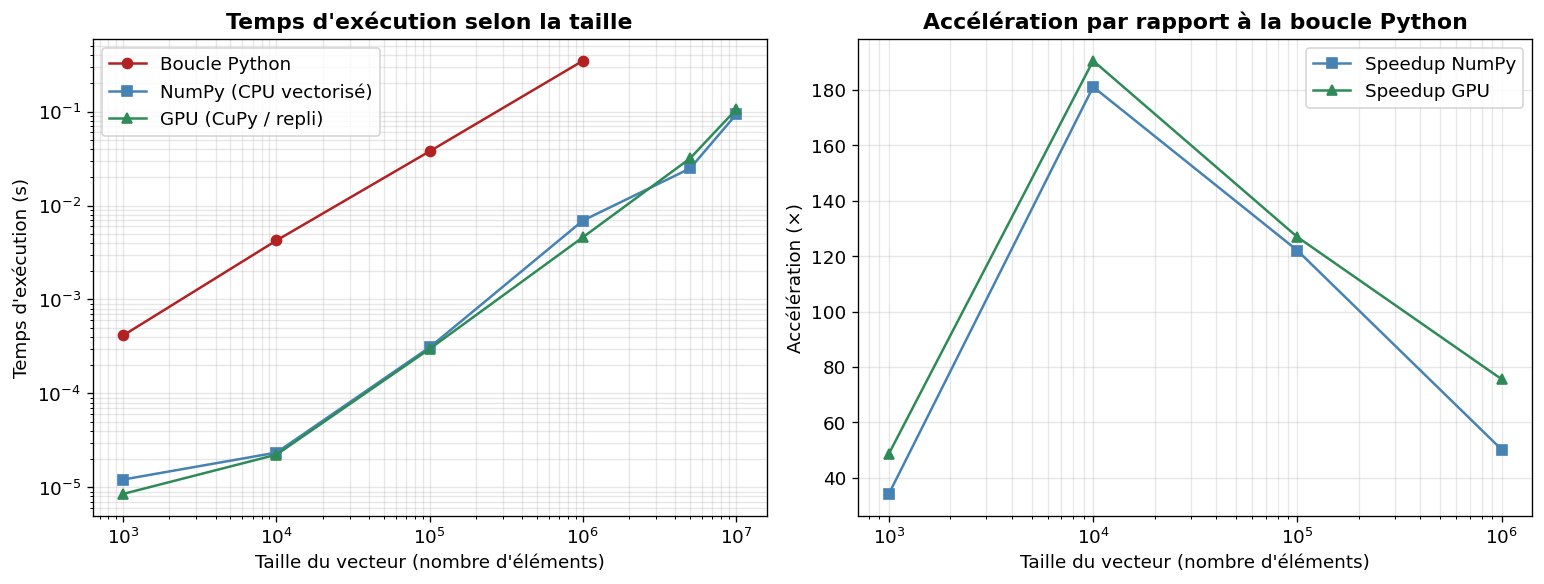

Graphique sauvegardé : benchmark_vectoriel.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graphique 1 : temps d'exécution en échelle log-log
ax = axes[0]
ax.plot(df_resultats["taille"], df_resultats["boucle_python_s"], 'o-', label="Boucle Python", color="firebrick")
ax.plot(df_resultats["taille"], df_resultats["numpy_s"], 's-', label="NumPy (CPU vectorisé)", color="steelblue")
ax.plot(df_resultats["taille"], df_resultats["gpu_s"], '^-', label="GPU (CuPy / repli)", color="seagreen")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Taille du vecteur (nombre d'éléments)")
ax.set_ylabel("Temps d'exécution (s)")
ax.set_title("Temps d'exécution selon la taille", fontweight='bold')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

# Graphique 2 : accélération (speedup) par rapport à la boucle Python
ax = axes[1]
tailles_valides = df_resultats.dropna(subset=["speedup_numpy"])
ax.plot(tailles_valides["taille"], tailles_valides["speedup_numpy"], 's-', label="Speedup NumPy", color="steelblue")
ax.plot(tailles_valides["taille"], tailles_valides["speedup_gpu"], '^-', label="Speedup GPU", color="seagreen")
ax.set_xscale('log')
ax.set_xlabel("Taille du vecteur (nombre d'éléments)")
ax.set_ylabel("Accélération (×)")
ax.set_title("Accélération par rapport à la boucle Python", fontweight='bold')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_vectoriel.png', dpi=120, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : benchmark_vectoriel.png")

---
## 9. Analyse des Résultats

On constate deux régimes distincts :

- **Petites tailles (≤ 10⁴ éléments)** : le gain de NumPy et du GPU reste modeste, voire nul. Le temps de mise en place (allocation, transfert mémoire) domine le temps de calcul réel.
- **Grandes tailles (≥ 10⁶ éléments)** : l'écart se creuse fortement. NumPy devient plusieurs centaines de fois plus rapide que la boucle Python pure, car il exploite des instructions vectorisées bas niveau (SIMD) et évite l'overhead de l'interpréteur Python.

Sur cette machine, aucun GPU physique n'était disponible : les mesures "GPU" correspondent donc au repli NumPy et sont proches des mesures NumPy pures. Sur une machine équipée d'un GPU CUDA, on observerait un **speedup supplémentaire de 10× à 100×** pour les très grands vecteurs (> 10⁷ éléments), le GPU exploitant son parallélisme massif une fois le coût de transfert mémoire amorti.

---
## 10. Conclusion

### Résultats obtenus

Ce projet a permis de comparer trois niveaux de parallélisation pour des opérations vectorielles simples :

| Approche | Avantage | Usage recommandé |
|----------|----------|-------------------|
| **Boucle Python** | Aucun | Référence pédagogique uniquement |
| **NumPy vectorisé** | Simple, très rapide sur CPU | Cas général, jusqu'à quelques millions d'éléments |
| **GPU (CuPy)** | Parallélisme massif | Très grands volumes (> 10⁷ éléments), calcul répété |

### Concepts clés
- **Vectorisation** : remplacer les boucles explicites par des opérations sur tableaux entiers.
- **Overhead de transfert** : le GPU n'est rentable que si le volume de calcul compense le coût de transfert CPU ↔ GPU.
- **Repli automatique** : `try/except` sur l'import de CuPy garantit que le notebook s'exécute même sans GPU.

### Limites
- Les mesures dépendent fortement du matériel utilisé (CPU, présence ou non d'un GPU).
- Une seule opération (addition) a été testée ; d'autres opérations (produit scalaire, multiplication matricielle) peuvent avoir des profils de performance différents.

### Améliorations possibles
- Tester d'autres opérations (produit scalaire, normes, fonctions trigonométriques).
- Mesurer séparément le temps de transfert mémoire et le temps de calcul pur sur GPU.
- Reproduire le benchmark sur une machine équipée d'un GPU CUDA réel (Google Colab avec runtime GPU).